In [13]:
import numpy as np
import tensorflow as tf
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re
import matplotlib.pyplot as plt
nltk.download('stopwords')
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
df=pd.read_csv('/content/combined_data.csv')

In [16]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [17]:
df.isnull().sum()

,0
label,0
text,0


In [18]:
df['text']=df['text'].str.lower()

In [19]:
import string
def remove_special(text):
  return text.translate(str.maketrans('','',string.punctuation))

df['text']=df['text'].apply(remove_special)

In [20]:
Stops=set(stopwords.words('english'))

In [21]:
def  remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)


In [22]:
df.head()

,label,text
0,1,"[ounce, feather, bowl, hummingbird, opec, mome..."
1,1,"[wulvob, get, medircations, online, qnb, ikud,..."
2,0,"[computer, connection, cnn, com, wednesday, es..."
3,1,"[university, degree, obtain, prosperous, futur..."
4,0,"[thanks, answers, guys, know, checked, rsync, ..."


In [23]:
df['text'] = df['text'].apply(' '.join)

In [24]:
df.head()


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [25]:
def remove_hyperlink(word):
    return re.sub(r"http\S+", "", word)

df['text'] = df['text'].apply(remove_hyperlink)

In [26]:
import pandas as pd
import re
from collections import Counter

# 1. Filter only spam emails
spam_df = df[df['label'] == 1]   # change to == 1 if spam is labeled as 1

# 2. Combine all spam text into one string
all_spam_text = " ".join(spam_df['text'])

# 3. Clean text (lowercase, remove special characters & numbers)
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")


Top 10 most frequent words in SPAM emails:
escapenumber : 337411
escapelong : 188118
com : 29009
http : 27775
per : 26143
x : 23863
pills : 23128
escapenumbermg : 20541
price : 18724
company : 15873


In [27]:
y=df['label']
X=df['text']

X_train, X_test,y_train,y_test=train_test_split(X, y, test_size=0.33, random_state=42)

In [28]:
max_features=5000
tokenizer=Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq=tokenizer.texts_to_sequences(X_train)
X_test_seq=tokenizer.texts_to_sequences(X_test)

In [29]:
avg_length=sum(map(len, X_train_seq))/len(X_train_seq)

In [30]:
max_length=500
X_train_pad=pad_sequences(X_train_seq,maxlen=max_length, padding='post')
X_test_pad=pad_sequences(X_test_seq,maxlen=max_length, padding='post')


In [31]:
embedding_length=32
max_length=500
max_features=5000


In [32]:
model_rnn=Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    SimpleRNN(64),
    Dense(1,activation='sigmoid')

])


model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
EPOCHS = 10
BATCH_SIZE = 64

In [36]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.9295 - loss: 0.1737 - val_accuracy: 0.9772 - val_loss: 0.0678
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9818 - loss: 0.0599 - val_accuracy: 0.9800 - val_loss: 0.0654
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9825 - loss: 0.0572 - val_accuracy: 0.9796 - val_loss: 0.0691
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9732 - loss: 0.0821 - val_accuracy: 0.9396 - val_loss: 0.1617
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9744 - val_loss: 0.0900
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9951 - loss: 0.0177 - val_accuracy: 0.9789 - val_loss: 0.0894
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.9940 - loss: 0.0191 - val_accuracy: 0.9799 - val_loss: 0.0880
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9962 - loss: 0.0130 - 

In [40]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


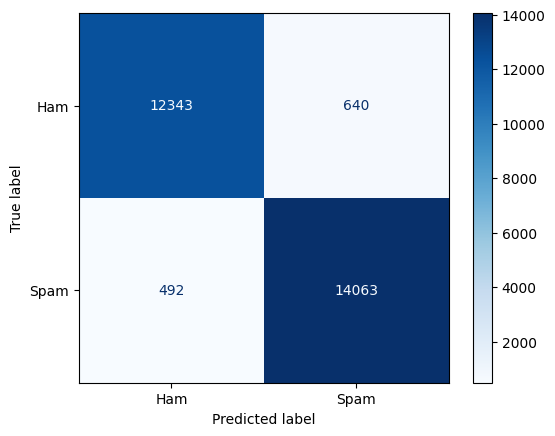

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     12983
           1       0.96      0.97      0.96     14555

    accuracy                           0.96     27538
   macro avg       0.96      0.96      0.96     27538
weighted avg       0.96      0.96      0.96     27538



In [43]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)


Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9642 - loss: 0.1086 - val_accuracy: 0.9802 - val_loss: 0.0625
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9824 - loss: 0.0596 - val_accuracy: 0.9824 - val_loss: 0.0544
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9885 - loss: 0.0387 - val_accuracy: 0.9830 - val_loss: 0.0542
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9903 - loss: 0.0332 - val_accuracy: 0.9830 - val_loss: 0.0590
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9930 - loss: 0.0237 - val_accuracy: 0.9841 - val_loss: 0.0546
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9926 - loss: 0.0248 - val_accuracy: 0.9850 - val_loss: 0.0551
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9877 - loss: 0.0386 - val_accuracy: 0.9846 - val_loss: 0.0528
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9932 - loss: 0.0224 - 

In [44]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.9583 - loss: 0.1243 - val_accuracy: 0.9814 - val_loss: 0.0635
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9848 - loss: 0.0519 - val_accuracy: 0.9849 - val_loss: 0.0470
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9888 - loss: 0.0408 - val_accuracy: 0.9853 - val_loss: 0.0480
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9921 - loss: 0.0282 - val_accuracy: 0.9804 - val_loss: 0.0601
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9915 - loss: 0.0327 - val_accuracy: 0.9859 - val_loss: 0.0474
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9932 - loss: 0.0241 - val_accuracy: 0.9858 - val_loss: 0.0493
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9948 - loss: 0.0206 - val_accuracy: 0.9854 - val_loss: 0.0502
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9959 - loss: 0.0145 - 

In [45]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)


861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [46]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9842036458711598


In [47]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98     12983
        Spam       0.99      0.98      0.99     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



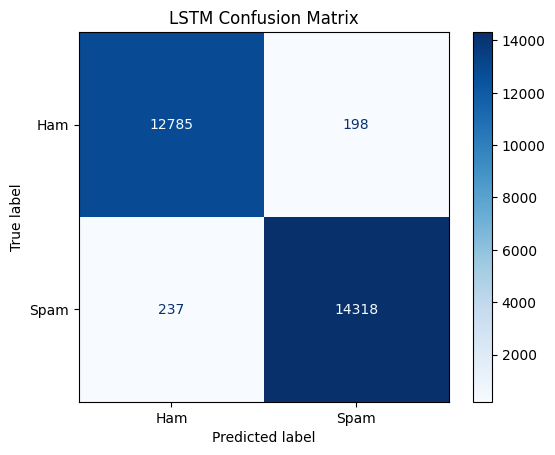

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()


In [49]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [50]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)


GRU Accuracy: 0.9853293630619507


In [51]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))

GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     12983
        Spam       0.98      0.99      0.99     14555

    accuracy                           0.99     27538
   macro avg       0.99      0.99      0.99     27538
weighted avg       0.99      0.99      0.99     27538



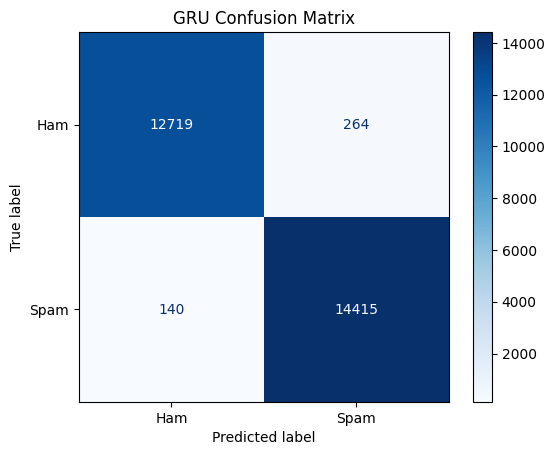

In [52]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()


In [53]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }


In [54]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.958893        0.956471     0.966197  0.961310
1        LSTM  0.984204        0.986360     0.983717  0.985037
2         GRU  0.985329        0.982015     0.990381  0.986180


In [55]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)


Best Model:
Model                  GRU
Accuracy          0.985329
Spam Precision    0.982015
Spam Recall       0.990381
Spam F1            0.98618
Name: 2, dtype: object


In [56]:
model_gru.save("gru_model.keras")

In [57]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [58]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [59]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)